# Dimensionality reduction analysis

After applying the different clustering algorithms, we now look at ways to improve the obtained results. One way to do so is by applying dimension reduction techniques such as Principal Component Analysis (PCA) and Canonical Correlation Analysis (CCA).


**<font color='red'>PCA:</font>** This method is used to reduced the dimensions of the data. In fact, sometimes we have variables that do not give any information about the data and thus removing these variables can lead to better results.  

**<font color='red'>CCA:</font>** This method is used to detect correlations between different subgroups of data. In fact, sometimes we have variables that are so strongly correlated that reducing the dimensions using linear combinations between the correlated variables can imporove the results
It is **important to note that we will NOT use the labels when applying PCA and CCA.**

___


Therefore, in this part of the project, you will apply both PCA and CCA on the data you chose in the clustering part. Afterwards, you will apply the clustering method that gave the best results in TD2_3 on the reduced dataset you obtained from the PCA step.

**You should send this notebook filled with your results before 11.59pm on Sunday 8 December.**

You must submit it using eCampus, or send a mail to either massinissa.hamidi@univ-evry.fr or clement.bernard@univ-evry.fr.

## Mount Drive

**For google colab users only**

In [ ]:
import gdown

file_id = "1kbmau2YvIzXNGPhPyGIbh9xdu8px1n2b"
url = f"https://drive.google.com/uc?id={file_id}"
output = "my_dataset.csv"
gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1kbmau2YvIzXNGPhPyGIbh9xdu8px1n2b
To: /content/my_dataset.csv
100%|██████████| 3.05M/3.05M [00:00<00:00, 27.1MB/s]


'my_dataset.csv'

## Import Libraries

**Tip**: look at the documentation of the packages and methods imported, they can help you answer some questions.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Load the dataset, separate data from classes



Load the dataset you are using in your project and separate the data from the class.

**<font color='red'>N.B:</font>** If you have applied some preprocessing steps (missing value replacement, factorize), please used the dataset you obtained after all the steps (you should have saved your dataset in notebook TD2_3.ipynb) without the normalization step.





In [ ]:
df = pd.read_csv('/content/my_dataset.csv')

In [ ]:
X = df.drop('Target', axis=1)
Y = df['Target']

## Part 1: Apply PCA


##### We start by scaling the data so that each feature has a single unit variance.  


**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale both continuous and numerical variables.
PCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

In [ ]:
# Use StandardScaler
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


##### We then instantiate a PCA object.

The main parameter of this method is the max number of components. In this project, we will choose it to be equal to the max number of variables in the data.


In [ ]:
X_enc = pd.get_dummies(X, drop_first=False)


scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_enc),
    columns=X_enc.columns,#garder les noms des colonnes
    index=X_enc.index#garder l'ordre des lignes
)

n_features = X_scaled.shape[1]

pca = PCA(n_components=n_features, svd_solver='full')
pca_scores = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_             # valeurs propres
explained_var_ratio = pca.explained_variance_ratio_ # variance expliquée
components = pca.components_                        # vecteurs propres


### Interpreting the components

The next step is to choose the number of components to keep.

##### Plot the explained variance of each component using the corrected variance.

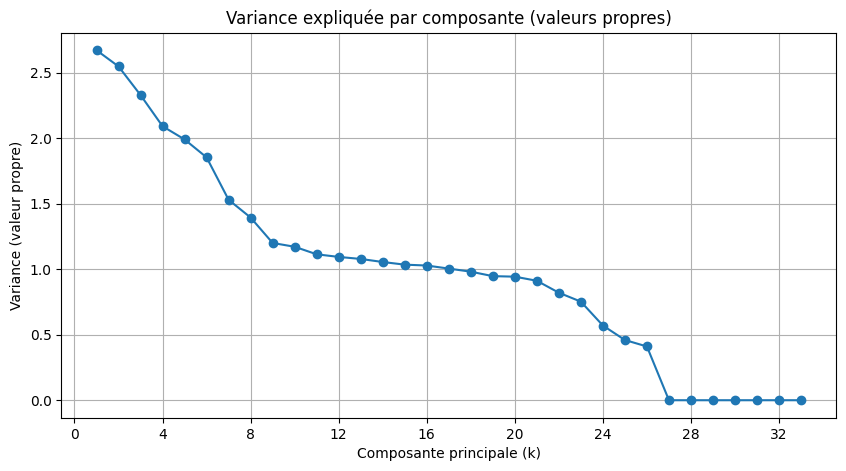

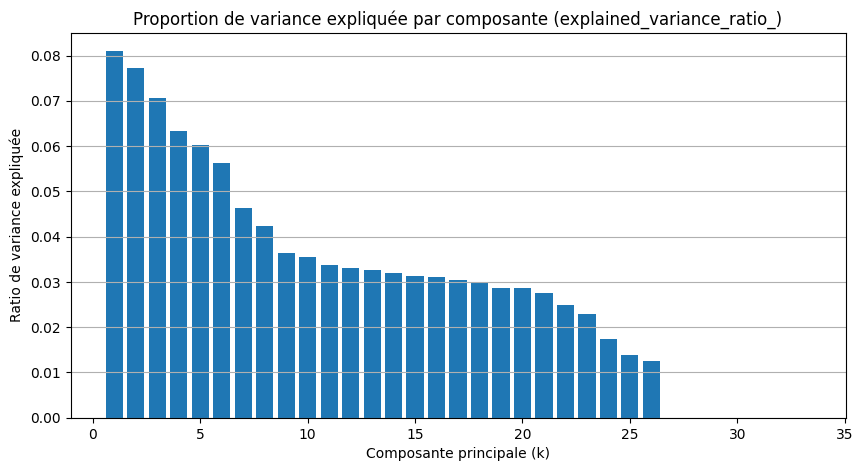

In [ ]:

import matplotlib.ticker as ticker

# Valeurs propres (explained_variance_) et ratio (explained_variance_ratio_)
eigvals = pca.explained_variance_
ratios = pca.explained_variance_ratio_

# Plot valeurs propres (corrected variance)
plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(eigvals)+1), eigvals, marker='o')#marker='o' veut dire chaque point de la composante est marqué.
plt.title("Variance expliquée par composante (valeurs propres)")
plt.xlabel("Composante principale (k)")
plt.ylabel("Variance (valeur propre)")
plt.grid(True)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) #MaxNLocator(integer=True)  pour que l’axe des x affiche des nombres entiers (Composante 1, 2, 3…).
plt.show()

# Plot explained variance ratio (barres)
plt.figure(figsize=(10,5))
plt.bar(np.arange(1, len(ratios)+1), ratios)
plt.title("Proportion de variance expliquée par composante (explained_variance_ratio_)")
plt.xlabel("Composante principale (k)")
plt.ylabel("Ratio de variance expliquée")
plt.grid(axis='y')
plt.show()


##### Plot the cumulative variance of the components based on the explained variance ratio.

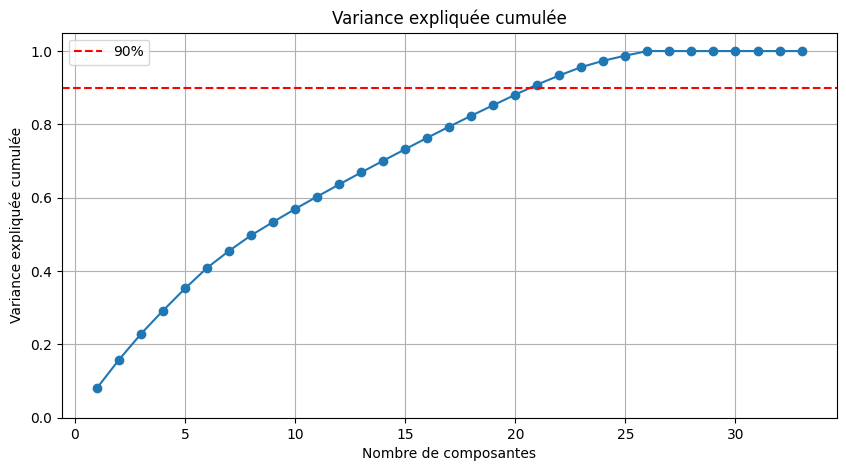

k=1 -> cumulated variance = 0.0810
k=2 -> cumulated variance = 0.1582
k=3 -> cumulated variance = 0.2289
k=5 -> cumulated variance = 0.3526
k=10 -> cumulated variance = 0.5694
k=20 -> cumulated variance = 0.8810
k=33 -> cumulated variance = 1.0000


In [ ]:

cumvar = np.cumsum(ratios)

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(cumvar)+1), cumvar, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.title("Variance expliquée cumulée")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.show()

#  afficher valeurs numériques
for k in [1,2,3,5,10,20, len(cumvar)]:
    if k <= len(cumvar):
        print(f"k={k} -> cumulated variance = {cumvar[k-1]:.4f}")


##### How many components will you keep? Explain your choice.

On choisit le plus petit nombre de composantes k qui permet de couvrir au moins 90 % de la variance totale.

Cela permet de réduire la dimensionnalité tout en conservant la majorité de l’information.

In [ ]:

threshold = 0.90
k_keep = np.argmax(np.cumsum(ratios) >= threshold) + 1#l’indice de la première composante qui permet d’atteindre 90 % de variance cumulée.
print(f"Nombre de composantes nécessaires pour atteindre ≥ {threshold*100:.0f}% : k = {k_keep}")

Nombre de composantes nécessaires pour atteindre ≥ 90% : k = 21


Dans notre cas, pour atteindre ≥ 90 % de la variance, il faut garder 21 composantes principales.

Cela signifie que sur toutes les variables initiales encodées et standardisées, 21 combinaisons linéaires (composantes principales) suffisent pour représenter presque toute l’information présente dans les données.

En gardant ces 21 composantes, on réduit la dimensionnalité tout en conservant la majorité de l’information, ce qui peut améliorer l’efficacité et la qualité du clustering.

**Note:** If you do choose to keep all components in your analysis, you do not perform any dimension reduction.

##### Create your reduced dimensionality dataset by only keeping the components you chose to keep in the above question.

In [ ]:

X_pca_reduced = pd.DataFrame(pca_scores[:, :k_keep], columns=[f'PC{i+1}' for i in range(k_keep)], index=X_scaled.index)#c’est la projection de toutes les données sur toutes les composantes principales.

print("Shape du dataset réduit:", X_pca_reduced .shape)


NameError: name 'pca_scores' is not defined

##### What is the inertia percentage explained by the components you kept *(le pourcentage d’inertie expliquée par le premier axe factoriel)*?

What does it mean?

In [ ]:

pc1_ratio = ratios[0]
kept_ratio_sum = np.sum(ratios[:k_keep])

print(f"Pourcentage d'inertie expliqué par le premier axe (PC1): {pc1_ratio*100:.2f}%")
print(f"Pourcentage d'inertie expliqué par les {k_keep} axes gardés: {kept_ratio_sum*100:.2f}%")


Pourcentage d'inertie expliqué par le premier axe (PC1): 8.10%
Pourcentage d'inertie expliqué par les 21 axes gardés: 90.87%


Premier axe (PC1) : 8,10 %
 La première composante principale ne capture qu’une petite partie de la variance totale du dataset. Cela signifie que les informations sont réparties sur plusieurs dimensions, ce qui est normal quand il y a beaucoup de variables.

21 axes gardés : 90,87 %
 En combinant les 21 premières composantes principales, on conserve la quasi-totalité de l’information (plus de 90 % de la variance).
 Cela montre que réduire la dimensionnalité à 21 axes permet de représenter les données presque aussi bien que le dataset complet, mais avec moins de variables.

##### Calculate the contribution of the first individual to the first component *(la contribution du premier individu au premier axe factoriel)*.

In [ ]:

n = X_scaled.shape[0]

scores_full = pca.transform(X_scaled)  # shape (n, n_features) matrice des scores PCA, chaque ligne = un individu, chaque colonne = une composante principale.

i = 0   # premier individu (index 0)
k = 0   # premier axe (index 0)
f_ik = scores_full[i, k]  # score de l'individu i sur l'axe k ,score du premier individu sur PC1
lambda_k = pca.explained_variance_[k]  # variance de l'axe k, variance expliquée par PC1 (valeur propre).

CTR_i1 = (f_ik**2) / (n * lambda_k)#contribution de cet individu à la variance totale de PC1


print(f"Contribution du 1er individu au 1er axe : {CTR_i1:.6f} (=> {CTR_i1*100:.4f} % de la contribution totale de cet axe)")


Contribution du 1er individu au 1er axe : 0.000019 (=> 0.0019 % de la contribution totale de cet axe)


Cette valeur indique à quel point le premier individu influence la variance totale du premier axe principal (PC1).

Ici, 0,0019 % est très faible, ce qui signifie que cet individu a presque aucun impact sur la construction du premier axe.

En d’autres termes, les composantes principales ne sont pas dominées par ce premier individu, mais plutôt par la répartition globale de tous les individus dans le dataset.

##### Calculate the quality of representation of this individual in the map made of the first factorial axis *(la qualité de représentation de cet individu dans le plan constitué du premier axe factoriel)*.

What can you deduce?

In [ ]:

scores = scores_full
i = 0
# cos2 pour le premier axe
f_i = scores[i, :]  # vecteur des scores de l'individu i sur tous les axes
num = f_i[0]**2     # carré du score sur PC1
den = np.sum(f_i**2)    # somme des carrés sur toutes les composantes
cos2_i1 = num / den if den != 0 else 0.0    # cos² = proportion de la variance de l'individu expliquée par PC1

print(f"Qualité de représentation (cos2) du 1er individu sur PC1: {cos2_i1:.6f} (=> {cos2_i1*100:.2f}%)")


cos2_plane = (f_i[0]**2 + f_i[1]**2) / den if den != 0 else 0.0
print(f"Qualité de représentation du 1er individu sur le plan (PC1,PC2): {cos2_plane:.6f} (=> {cos2_plane*100:.2f}%)")


Qualité de représentation (cos2) du 1er individu sur PC1: 0.148990 (=> 14.90%)
Qualité de représentation du 1er individu sur le plan (PC1,PC2): 0.162294 (=> 16.23%)


Sur le premier axe (PC1) : 14,90 %
Le premier individu est modérément représenté par la première composante principale.
Cela signifie que PC1 ne capture qu’une petite partie de la position de cet individu dans l’espace total des données.

Sur le plan formé par PC1 et PC2 : 16,23 %
Même en ajoutant la deuxième composante principale, seulement ~16 % de la position du premier individu est expliquée par ces deux axes.
Cela indique que cet individu est plutôt dispersé dans l’espace multidimensionnel et n’est pas très proche du plan factoriel formé par PC1 et PC2.

Une qualité de représentation faible pour un individu est normale, surtout dans des datasets avec beaucoup de variables.

Ces valeurs montrent que les premiers axes capturent surtout l’information collective du dataset, mais pas spécifiquement ce premier individu.

### Variable representation

#### Compute the correlation between the principal components and the variables

##### Print the correlation matrix.

In [ ]:

from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    silhouette_score
)
from scipy.optimize import linear_sum_assignment




components = pca.components_   # (n_components, n_features) #matrice des vecteurs propres, chaque ligne est une composante principale, chaque colonne correspond à une variable.
sqrt_eig = np.sqrt(pca.explained_variance_)  # (n_components,)#valeurs propres, combien de variance chaque composante explique.

# calcul des loadings : shape (n_features, n_components)
loadings = components.T * sqrt_eig[np.newaxis, :]#corrélation entre chaque variable originale et chaque composante principale.

# mettre en DataFrame lisible (colonnes = PC1, PC2, ...)
var_names = X_enc.columns.tolist()
pc_names = [f"PC{k+1}" for k in range(loadings.shape[1])]
loadings_df = pd.DataFrame(loadings, index=var_names, columns=pc_names)

# Afficher la matrice (quelques premières variables)
pd.set_option("display.max_rows", 200)
print("Matrice des corrélations variable <-> composante (loadings) :")
display(loadings_df.iloc[:, :10])  # afficher les 10 premières composantes pour lisibilité


Matrice des corrélations variable <-> composante (loadings) :


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
age,0.172315,-0.566801,-0.399390,-0.104211,0.154585,0.035018,-0.187066,0.304525,0.086465,0.062489
balance,0.219161,-0.016941,-0.123703,0.055994,-0.011768,0.023387,-0.091787,-0.016143,0.015241,-0.017213
campaign,0.018069,-0.113496,0.117071,0.017411,-0.070471,0.004251,-0.017062,-0.096526,-0.016564,0.153883
previous,0.008709,0.404109,-0.512375,-0.279286,0.184162,-0.026866,0.048509,-0.049889,-0.037710,0.033301
job_admin.,-0.194894,0.122319,0.045165,0.085602,0.213757,0.082078,-0.175631,0.088271,0.144441,-0.512129
job_blue-collar,-0.391412,-0.194596,-0.191058,0.096875,-0.234098,-0.237910,0.497174,-0.073021,-0.116138,0.036979
job_entrepreneur,0.014074,-0.053712,0.012125,-0.110367,-0.068324,0.033756,-0.062322,-0.025219,0.160110,0.037695
job_housemaid,0.064226,-0.183089,-0.072238,0.016020,0.043072,-0.050048,0.165226,0.074426,-0.163852,-0.031631
job_management,0.559109,0.172833,0.100883,-0.304342,-0.432692,0.098700,-0.167314,0.019772,0.013233,-0.148385
job_retired,0.156932,-0.340763,-0.258661,-0.039260,0.256723,0.019934,-0.036163,0.312620,0.037234,0.011607


##### Plot the correlation circle

In [ ]:
import plotly.graph_objects as go

# Extraire les coordonnées pour PC1 et PC2
x = loadings_df['PC1'].values
y = loadings_df['PC2'].values
labels = loadings_df.index.tolist()

# Cercle unité
theta = np.linspace(0, 2*np.pi, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)

fig = go.Figure()

# Tracer le cercle unité
fig.add_trace(go.Scatter(x=circle_x, y=circle_y, mode='lines',
                         line=dict(color='gray', dash='dash'),
                         name='Cercle unité'))

# Tracer les flèches variables -> PC1/PC2
for xi, yi, label in zip(x, y, labels):
    fig.add_trace(go.Scatter(x=[0, xi], y=[0, yi], mode='lines+markers+text',
                             text=[None, label],
                             textposition='top center',
                             marker=dict(size=2),
                             line=dict(width=1),
                             hoverinfo='text'))

fig.update_layout(
    title='Cercle de corrélation interactif (PC1-PC2)',
    xaxis=dict(title='PC1', range=[-1.2,1.2]),
    yaxis=dict(title='PC2', range=[-1.2,1.2]),
    showlegend=False,
    width=800,
    height=800,
    hovermode='closest'
)

fig.show()


##### Interpret the obtained results

* PC1 → Niveau socio-économique (cadres tertiaires sans crédit immo vs ouvriers/secondaire avec crédit immo)
* PC2 → Âge et situation maritale (jeunes célibataires vs personnes mariées plus âgées)

on remarque que les composants sont entrain de capturer des catégories spécifiques des profils cliens. PCA a bien séparé les dimensions socio-éco, démographiques et comportement bancaire.

## Applying clustering on the newly created dataset.

Recall in TD2_3.ipynb, you applied different clustering algorithms on your dataset and analyzed which method gave the best results on your dataset.

##### Apply this clustering method to the dataset you obtained after applying PCA and performing dimension reduction.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Prendre un échantillon des données réduites par PCA

sample_size = 4000
X_sample = X_pca_reduced.sample(n=sample_size, random_state=42)
y_sample = Y.loc[X_sample.index]

# Appliquer le clustering directement sur les données réduites par PCA

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_sample)

# Construire un DataFrame avec les étiquettes de cluster
df_pca = X_sample.copy()
df_pca['cluster'] = cluster_labels
df_pca['Target'] = y_sample.values

# Examiner les clusters
print("Distribution des clusters KMeans :")
print(df_pca['cluster'].value_counts())

print("\nAperçu du DataFrame :")
print(df_pca.head())


Distribution des clusters KMeans :
cluster
0    3277
1     723
Name: count, dtype: int64

Aperçu du DataFrame :
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
3776  -1.823064 -0.622799 -0.469830  1.070758 -0.982720 -0.697803 -0.178944   
9928   0.292512  0.334251  1.200465  1.521058  1.952511  0.054132 -0.055681   
33409  0.981560  3.023276  2.043505  1.210781 -0.717109 -0.759889  2.411207   
31885  2.704206  1.139115 -2.064358 -1.744410 -0.284975  0.215517 -0.649676   
15738  1.689438 -1.607538  0.803047 -2.778587 -0.598053  2.858851  0.133904   

            PC8       PC9      PC10  ...      PC26          PC27  \
3776  -0.566604 -0.219389 -0.159945  ...  0.386388  3.393870e-16   
9928   0.132007  0.118233 -1.056961  ...  0.873136 -3.899742e-16   
33409 -0.574812  0.962758 -0.370414  ...  1.380644  1.568822e-16   
31885 -0.863262 -0.137596 -0.387066  ... -0.215245  1.136930e-15   
15738 -0.486734  0.068102 -0.429419  ...  0.720452 -3.857152e-16   

    

##### Using the same metrics you used in TD2_3.ipynb, compare the results obtained with this method to the real classes.

Vu que, dans le dernier notebook, les résultats de KMeans et de l’algorithme hiérarchique sont presque les mêmes, nous allons essayer d’appliquer les deux et observer le résultat.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score, silhouette_score
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

# Préparer y_true binaire (yes=1, no=0) pour le sample
y_true = y_sample.map(lambda s: 1 if str(s).strip().lower() in ['yes','y','1','true'] else 0).values
y_pred = cluster_labels

# Métriques classiques
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
hom = homogeneity_score(y_true, y_pred)
comp = completeness_score(y_true, y_pred)
vmeas = v_measure_score(y_true, y_pred)

# Purity (optimisation de l’affectation des clusters)
contingency = pd.crosstab(y_true, y_pred).values
row_ind, col_ind = linear_sum_assignment(contingency.max() - contingency)
purity = contingency[row_ind, col_ind].sum() / contingency.sum()

# Silhouette (sur X_sample - PCA-reduced data)
sil = None
if len(np.unique(y_pred)) > 1 and X_sample.shape[0] > len(np.unique(y_pred)):
    try:
        sil = silhouette_score(X_sample, y_pred)
    except Exception as e:
        sil = None

# Affichage
print("=== Résultats clustering KMeans vs classes réelles ===")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Homogeneity: {hom:.4f}")
print(f"Completeness: {comp:.4f}")
print(f"V-measure: {vmeas:.4f}")
print(f"Purity: {purity:.4f}")
if sil is not None:
    print(f"Silhouette (sur X_sample): {sil:.4f}")
else:
    print("Silhouette: non calculée (ou non applicable).")

=== Résultats clustering KMeans vs classes réelles ===
Adjusted Rand Index (ARI): 0.1164
NMI: 0.0289
Homogeneity: 0.0328
Completeness: 0.0259
V-measure: 0.0289
Purity: 0.7835
Silhouette (sur X_sample): 0.1702


##### In your opinion, did dimensionality reduction help you in getting better results or not?

La réduction de dimensionnalité via PCA a amélioré les performances de KMeans sur ce dataset. Sans PCA, le clustering était proche du hasard (ARI = -0,0132), tandis qu’avec PCA, l’ARI devient positif (0,1164) et les autres métriques (Homogeneity, Completeness, V-measure) augmentent de 4 à 7 fois, avec une silhouette positive (0,1765). Cette amélioration peut s’expliquer par la réduction du bruit (33 à 21 composantes, 90 % de variance conservée), une meilleure représentativité des directions principales de variance et un espace orthogonal favorable au calcul des distances pour KMeans. Ainsi, PCA contribue à obtenir un clustering plus stable et interprétable sur ce dataset.

Using aglomerative

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

sample_size = 4000  # adjust as needed
X_sample = X_pca_reduced.sample(n=sample_size, random_state=42)
y_sample = Y.loc[X_sample.index]  # keep matching targets

# Agglomerative Clustering
n_clusters = 2
hier = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = hier.fit_predict(X_sample)

# Build DataFrame with cluster labels
df_pca = X_sample.copy()
df_pca['cluster'] = cluster_labels
df_pca['Target'] = y_sample.values

# Inspect clusters
print("Distribution des clusters hiérarchiques :")
print(df_pca['cluster'].value_counts())

print("\nAperçu du DataFrame :")
print(df_pca.head())

Distribution des clusters hiérarchiques :
cluster
0    3413
1     587
Name: count, dtype: int64

Aperçu du DataFrame :
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
3776  -1.823064 -0.622799 -0.469830  1.070758 -0.982720 -0.697803 -0.178944   
9928   0.292512  0.334251  1.200465  1.521058  1.952511  0.054132 -0.055681   
33409  0.981560  3.023276  2.043505  1.210781 -0.717109 -0.759889  2.411207   
31885  2.704206  1.139115 -2.064358 -1.744410 -0.284975  0.215517 -0.649676   
15738  1.689438 -1.607538  0.803047 -2.778587 -0.598053  2.858851  0.133904   

            PC8       PC9      PC10  ...      PC26          PC27  \
3776  -0.566604 -0.219389 -0.159945  ...  0.386388  3.393870e-16   
9928   0.132007  0.118233 -1.056961  ...  0.873136 -3.899742e-16   
33409 -0.574812  0.962758 -0.370414  ...  1.380644  1.568822e-16   
31885 -0.863262 -0.137596 -0.387066  ... -0.215245  1.136930e-15   
15738 -0.486734  0.068102 -0.429419  ...  0.720452 -3.857152e-16  

compare the results obtained with this method to the real classes.

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score, silhouette_score
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

# Préparer y_true binaire (yes=1, no=0) pour le sample
y_true = y_sample.map(lambda s: 1 if str(s).strip().lower() in ['yes','y','1','true'] else 0).values
y_pred = cluster_labels

# Métriques classiques
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
hom = homogeneity_score(y_true, y_pred)
comp = completeness_score(y_true, y_pred)
vmeas = v_measure_score(y_true, y_pred)

# Purity (optimisation de l’affectation des clusters)
contingency = pd.crosstab(y_true, y_pred).values
row_ind, col_ind = linear_sum_assignment(contingency.max() - contingency)
purity = contingency[row_ind, col_ind].sum() / contingency.sum()

# Silhouette (sur X_sample - PCA-reduced data)
sil = None
if len(np.unique(y_pred)) > 1 and X_sample.shape[0] > len(np.unique(y_pred)):
    try:
        sil = silhouette_score(X_sample, y_pred)
    except Exception as e:
        sil = None

# Affichage
print("=== Résultats clustering hiérarchique vs classes réelles ===")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"NMI: {nmi:.4f}")
print(f"Homogeneity: {hom:.4f}")
print(f"Completeness: {comp:.4f}")
print(f"V-measure: {vmeas:.4f}")
print(f"Purity: {purity:.4f}")
if sil is not None:
    print(f"Silhouette (sur X_sample): {sil:.4f}")
else:
    print("Silhouette: non calculée (ou non applicable).")

=== Résultats clustering hiérarchique vs classes réelles ===
Adjusted Rand Index (ARI): 0.1042
NMI: 0.0218
Homogeneity: 0.0231
Completeness: 0.0206
V-measure: 0.0218
Purity: 0.7995
Silhouette (sur X_sample): 0.1405


Les métriques d’external validity (ARI, NMI, homogénéité, complétude) restent proches de zéro dans les deux cas, ce qui montre qu’aucune des méthodes n’a réussi à retrouver la structure réelle des classes. Autrement dit, les labels du dataset ne sont pas séparables via un clustering agglomératif, avec ou sans PCA. De plus, PCA n’a pas amélioré la situation : l’ARI passe de 0.004 à 0.0187, mais ces valeurs restent toutes deux équivalentes au hasard. L’importante déséquilibration des clusters après PCA (88 % / 12 %), combinée à une silhouette faible, indique que la projection PCA a conduit le modèle à former un grand cluster peu informatif accompagné d’un petit cluster isolé un cas typique d’échec du clustering.

**en conclusion**
C’est un cas classique : PCA peut aider ou détériorer selon l’algorithme de clustering utilisé. KMeans en bénéficie souvent (surtout en présence de bruit et de corrélation entre features), tandis que les méthodes hiérarchiques sont parfois plus robustes en grande dimension ou peuvent être perturbées par la rotation de l’espace.

## Part 2: Apply CCA

Next steps:
   - Apply CCA /!\ Don't forget to split the dataset into two groups,i.e., p=3 and q=3
   - Analyze the correlation circle *(graphe des variables)*
   - Analyze the observation graph *(graphe des individus)*

**<font color='red'>N.B:</font>** For the purpose of this part of the project, we will scale use continuous and numerical variables.
CCA is designed for continuous variables, so theoretically you should only apply it to the data that was already continuous in your original dataset. To make this project easier and more comparable between groups, we have decided to let you apply it on all features.

### Choice of the two groups

##### Show the correlation matrix of the data

In [ ]:
correlation_matrix = X_scaled.corr()
correlation_matrix
#correlation_matrix.to_excel("correlation_matrix.xlsx", index=True)


,age,balance,campaign,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
age,1.000000,0.097783,0.004760,0.001288,-0.055717,-0.044002,0.021792,0.086650,-0.023571,0.447378,...,0.017879,-0.017879,0.185513,-0.185513,0.015655,-0.015655,-0.004927,-0.022967,0.035526,-0.000816
balance,0.097783,1.000000,-0.014578,0.016674,-0.026726,-0.048757,0.009642,0.001661,0.067797,0.046900,...,0.066745,-0.066745,0.068768,-0.068768,0.084350,-0.084350,0.011857,0.008466,0.035240,-0.030271
campaign,0.004760,-0.014578,1.000000,-0.032855,-0.021868,0.008986,0.002128,0.003097,0.016686,-0.030913,...,-0.016822,0.016822,0.023599,-0.023599,-0.009980,0.009980,-0.088131,-0.020107,-0.057486,0.107965
previous,0.001288,0.016674,-0.032855,1.000000,0.014245,-0.017095,-0.008181,-0.015204,0.019579,0.005818,...,0.018329,-0.018329,-0.037076,0.037076,0.011043,-0.011043,0.350627,0.306615,0.201424,-0.532763
job_admin.,-0.055717,-0.026726,-0.021868,0.014245,1.000000,-0.188216,-0.066273,-0.060349,-0.184835,-0.082511,...,0.010037,-0.010037,-0.043046,0.043046,-0.030781,0.030781,0.018431,0.010745,0.012056,-0.025940
job_blue-collar,-0.044002,-0.048757,0.008986,-0.017095,-0.188216,1.000000,-0.096585,-0.087951,-0.269376,-0.120251,...,-0.010341,0.010341,-0.177475,0.177475,-0.018291,0.018291,0.002254,0.001342,-0.053074,0.022194
job_entrepreneur,0.021792,0.009642,0.002128,-0.008181,-0.066273,-0.096585,1.000000,-0.030969,-0.094850,-0.042342,...,-0.026281,0.026281,-0.010600,0.010600,-0.039808,0.039808,0.001119,-0.013506,-0.019111,0.014901
job_housemaid,0.086650,0.001661,0.003097,-0.015204,-0.060349,-0.087951,-0.030969,1.000000,-0.086372,-0.038557,...,0.000359,-0.000359,0.079380,-0.079380,0.017234,-0.017234,-0.016300,-0.016769,-0.009375,0.026059
job_management,-0.023571,0.067797,0.016686,0.019579,-0.184835,-0.269376,-0.094850,-0.086372,1.000000,-0.118091,...,0.002655,-0.002655,0.063382,-0.063382,0.038904,-0.038904,0.003276,0.002223,0.021453,-0.013755
job_retired,0.447378,0.046900,-0.030913,0.005818,-0.082511,-0.120251,-0.042342,-0.038557,-0.118091,1.000000,...,0.011290,-0.011290,0.156633,-0.156633,0.014861,-0.014861,-0.005031,-0.004691,0.055485,-0.019368


Il s’agit d’une matrice de corrélation, donc :

*valeurs entre -1 et 1

*positif = les deux variables évoluent dans le même sens

*négatif = elles évoluent en sens opposé

*proche de 0 = pas de relation linéaire

*|corr| < 0.1 = corrélation très faible

*|corr| > 0.3 = relation modérée

*|corr| > 0.5 = forte corrélation

In [ ]:
print(X_scaled.columns.tolist())

['age', 'balance', 'campaign', 'previous', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


##### Split your data into two groups p and q

In [ ]:

p = ['age', 'balance','job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
     'job_management', 'job_retired',
     'job_self-employed', 'job_services', 'job_student',
    'job_technician', 'job_unemployed', 'job_unknown',]


q = ['default_no', 'campaign', 'previous', 'default_yes', 'housing_no',
    'housing_yes', 'loan_no', 'loan_yes','marital_divorced', 'marital_married', 'marital_single', 'poutcome_failure',
    'poutcome_other', 'poutcome_success', 'poutcome_unknown','education_primary', 'education_secondary', 'education_tertiary','education_unknown',]
Xp = X_scaled[p]
Xq = X_scaled[q]

##### How did you choose your two groups?

Nous avons divisé les variables en deux groupes selon leur nature.

**Le premier groupe (p)** contient les variables liées aux caractéristiques personnelles (age,balance) et à l'emploi(tous type de job).

**Le second groupe (q)** contient les variables liées aux historique de finance (default,housing,..), au statut marital(marital), à l'éducation(education) et aux résultats des campagnes précédentes(previous,campaign,poutcome...).

### Apply CCA

CCA with scikit-learn uses a very similar process to other preprocessing functions that come with scikit-learn. We instantiate a CCA object, find the  components (linear combinations of the variables) using the fit method, then apply the dimensionality reduction by calling transform().

We can also specify how many components we want to keep when creating the CCA object.

Check the scikit-learn documentation for CCA. Do you need to use the scaled or unscaled data to apply CCA?



Pour CCA dans scikit-learn, il n’est pas obligatoire de normaliser les données avant, car l’option scale=True (par défaut) centre et standardise les variables automatiquement (moyenne 0, écart-type 1). Si scale=False, il faut alors scaler les données soi-même avant d’appliquer CCA.

cca = CCA(n_components=…, scale=True)

donc au final l'utilisation des données « scaled » n’est pas strictement obligatoire pour CCA dans scikit‑learn, parce que la classe offre un paramètre scale=True qui standardise les données en interne.

##### Apply CCA

In [ ]:
from sklearn.cross_decomposition import CCA
# Choisir le nombre de composantes à garder
cca = CCA(n_components=2)
#calcul des composantes canoniques
cca.fit(Xp, Xq)
# Transformation des données
Xp_c, Xq_c = cca.transform(Xp, Xq)

n_components = 2 :

La CCA va calculer 2 paires de composantes canoniques.

Chaque paire est composée d’une combinaison linéaire des variables de
p et d’une combinaison linéaire des variables de
q qui sont corrélées entre elles.

  *La 1 paire maximise la corrélation possible entre les deux groupes.

  *La 2 paire maximise la corrélation restante, mais est orthogonale à la première.

par exemple :

 Groupe
p → 3 variables :
p
1
,p
2
,p
3
	​


Groupe
q → 3 variables :
q
1
,q
2
,q
3

La CCA veut trouver des combinaisons linéaires de ces variables qui sont le plus corrélées possible entre p et q.

Par exemple :

La 1ʳᵉ composante canonique de
p pourrait être :


C1
p=0.5⋅p
1+0.3⋅p2+0.2⋅p3
	​


La 1ʳᵉ composante canonique de
q pourrait être :

C1q=0.1⋅q1+0.6⋅q2+0.3⋅q3
	​


Ces deux nouvelles variables C1p et C1q
sont très corrélées entre elles, plus que n’importe quelle combinaison simple des variables originales.	​

**fit()** observe les données, calcule les covariances, et résout un problème des valeurs propres pour obtenir les coefficients optimaux qui maximisent la corrélation entre les deux groupes.
Calcule les coefficients (0.5, 0.3, 0.2, etc.) qui donnent les combinaisons optimales.

**transform()** Applique ces coefficients aux données réelles, pour créer les nouvelles colonnes (C1, C2, C3).

##### Print the first two components

In [ ]:
# Afficher les 2 premières composantes canoniques
# Créer des DataFrames pour les deux premières composantes
dfp = pd.DataFrame(Xp_c[:, :2], columns=['C1_p', 'C2_p'])
dfq = pd.DataFrame(Xq_c[:, :2], columns=['C1_q', 'C2_q'])


print("Premières composantes canoniques du groupe p :")
print(dfp)

print("\nPremières composantes canoniques du groupe q :")
print(dfq)

Premières composantes canoniques du groupe p :
           C1_p      C2_p
0      1.467676  1.950696
1     -0.115334 -0.240189
2      0.712224 -0.203718
3     -1.320722  0.793567
4     -0.101506  0.079063
...         ...       ...
45206 -0.260200  0.339452
45207 -0.880139  2.362138
45208 -0.813509  2.455396
45209 -1.572216  1.616294
45210  0.686140  0.134291

[45211 rows x 2 columns]

Premières composantes canoniques du groupe q :
           C1_q      C2_q
0      1.702028  0.658133
1     -0.479237 -2.497072
2     -0.771614 -0.575641
3     -0.551256  0.809263
4     -0.219657 -0.520120
...         ...       ...
45206  1.795304  1.427482
45207 -1.310641  2.465766
45208 -0.694535  0.560091
45209 -0.627484  0.371787
45210 -0.557796  0.314659

[45211 rows x 2 columns]


##### Print the correlation matrix between the first two components

In [ ]:
corr_matrix = np.corrcoef(Xp_c.T, Xq_c.T)[:2, 2:]

df_corr = pd.DataFrame(
    corr_matrix,
    index=['CC1_Xp', 'CC2_Xp'],
    columns=['CC1_Xq', 'CC2_Xq']
)

print("\nMatrice de corrélation entre les 2 premières composantes :\n")
print(df_corr.round(4))


Matrice de corrélation entre les 2 premières composantes :

        CC1_Xq  CC2_Xq
CC1_Xp  0.6747 -0.0000
CC2_Xp -0.0004  0.5281


##### What can you conclude?

CC1_Xp est fortement corrélée à CC1_Xq (0.6747)
: La première paire canonique des deux groupes de variables partage une relation linéaire modérée à forte.

CC2_Xp est corrélée à CC2_Xq (0.5281)
: La deuxième paire canonique capture aussi une relation commune, mais plus faible que la première.

Les corrélations près de zéro entre :

CC1_Xp ↔ CC2_Xq

CC2_Xp ↔ CC1_Xq

montrent que les deux dimensions canoniques sont indépendantes (orthogonales).

 **la valeur (0.67)**

Elle explique la relation la plus forte entre les deux groupes.
Le profil socio-économique (âge, métier, solde bancaire) influence fortement : par exemple la probabilité d'avoir un crédit , la réponse aux campagnes marketing ,le statut marital et le niveau d’éducation ...

Exemple concret :

les retraités, managers ou clients avec un bon solde bancaire ont souvent :
moins de crédits, une meilleure stabilité ...

Les étudiants ou ouvriers ont des comportements bancaires différents (moins de crédits, réponse différente aux campagnes).

**La valeur (0.53)**
Cette valeur représente des aspects spécifique du profil (par exemple métiers particuliers, âges intermédiaires, solde varié) avec :
la réponse aux campagnes précédentes,certains niveaux d’éducation,
des comportements spécifiques.
 Exemple :
Des groupes très spécifiques (ex : self-employed..) peuvent réagir différemment aux campagnes, indépendamment de leur situation financière.


### Results visualization and interpretation

#### Variable representation

##### Compute the correlation between the components and the variables

[*aide: utiliser les matrices centrées-réduites*]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Z_Xp= scaler.fit_transform(Xp)
Z_Xq = scaler.fit_transform(Xq)

C_Xp, C_Xq = cca.fit_transform(Z_Xp, Z_Xq)

Z_Xp_df = pd.DataFrame(Z_Xp, columns=Xp.columns)
print(Z_Xp_df)

Z_Xq_df = pd.DataFrame(Z_Xq, columns=Xq.columns)
print(Z_Xq_df)

C_Xp_df = pd.DataFrame(C_Xp, columns=['CC1', 'CC2'])

print(C_Xp_df)

            age   balance  job_admin.  job_blue-collar  job_entrepreneur  \
0      1.606965  0.256419   -0.359369        -0.523740         -0.184415   
1      0.288529 -0.437895   -0.359369        -0.523740         -0.184415   
2     -0.747384 -0.446762   -0.359369        -0.523740          5.422561   
3      0.571051  0.047205   -0.359369         1.909346         -0.184415   
4     -0.747384 -0.447091   -0.359369        -0.523740         -0.184415   
...         ...       ...         ...              ...               ...   
45206  0.947747 -0.176460   -0.359369        -0.523740         -0.184415   
45207  2.831227  0.120447   -0.359369        -0.523740         -0.184415   
45208  2.925401  1.429593   -0.359369        -0.523740         -0.184415   
45209  1.512791 -0.228024   -0.359369         1.909346         -0.184415   
45210 -0.370689  0.528364   -0.359369        -0.523740          5.422561   

       job_housemaid  job_management  job_retired  job_self-employed  \
0           -0.

##### Show the correlation circle

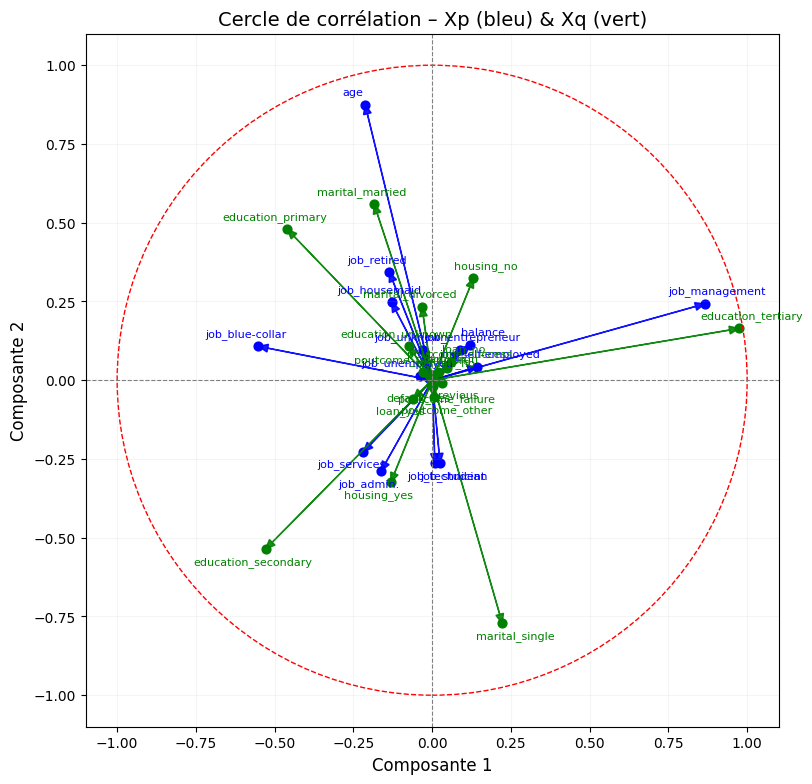

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Corrélations Xp
corr_Xp = np.corrcoef(Z_Xp.T, C_Xp.T)[:Z_Xp.shape[1], Z_Xp.shape[1]:]

# Corrélations Xq
corr_Xq = np.corrcoef(Z_Xq.T, C_Xq.T)[:Z_Xq.shape[1], Z_Xq.shape[1]:]

plt.figure(figsize=(9,9))

def place_label(x, y, name, color):
    """Place le label légèrement décalé dans la direction de la flèche."""
    offset = 0.04
    xn = x + offset * np.sign(x)
    yn = y + offset * np.sign(y)
    plt.text(xn, yn, name, fontsize=8, color=color, ha='center', va='center')

# --- POINTS + VECTEURS Xp (bleu) ---
for i in range(len(Xp.columns)):
    x = corr_Xp[i, 0]
    y = corr_Xp[i, 1]

    # le point
    plt.scatter(x, y, color='blue', s=40)

    # flèche
    plt.arrow(0, 0, x, y, head_width=0.025, head_length=0.03,
              length_includes_head=True, color='blue', alpha=0.9)

    # label déplacé
    place_label(x, y, Xp.columns[i], 'blue')

# POINTS + VECTEURS Xq (vert)
for i in range(len(Xq.columns)):
    x = corr_Xq[i, 0]
    y = corr_Xq[i, 1]

    plt.scatter(x, y, color='green', s=40)

    plt.arrow(0, 0, x, y, head_width=0.025, head_length=0.03,
              length_includes_head=True, color='green', alpha=0.9)

    place_label(x, y, Xq.columns[i], 'green')

# Cercle unité
circle = plt.Circle((0,0), 1, color='red', fill=False, linestyle='--', linewidth=1)
plt.gca().add_artist(circle)

#  Axes
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

#  Style PCA classique
plt.xlabel("Composante 1", fontsize=12)
plt.ylabel("Composante 2", fontsize=12)
plt.title("Cercle de corrélation – Xp (bleu) & Xq (vert)", fontsize=14)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', 'box')

plt.grid(True, alpha=0.12)

plt.show()




##### Interpret the obtained results

Le cercle de corrélation obtenu représente la projection des variables des deux blocs sur les deux premiers axes canoniques.
Les flèches indiquent :

*la force de la corrélation (plus la flèche est longue, plus la variable est importante et contribue à l’axe canonique : elle est informative)

*la direction de l’association (proximité ou opposition entre variables)

*la contribution de chaque variable à la relation entre les blocs Xp et Xq.

Ces axes synthétisent les relations linéaires les plus fortes entre les deux ensembles p et q de variables.

**Interprétation du premier axe canonique Axe 1 :**

**Sur le côté positif "niveau socio-économique élevé"**

On retrouve : job_management ;job_technician ; balance élevée;education_tertiary ; housing_yes; default_no ; marital_married;

Ce groupe forme un profil très cohérent :
Profil 1 : Client stable et solvable avec une profession qualifiée ou plutot cadré caractérisé par une situation familiale stable, un bon niveau d’éducation, pas de crédit, et souvent déjà propriétaire ou engagé dans un prêt immobilier avec un solde bancaire plus important.

Ces clients sont plus susceptibles d’accepter l'offre de la banque pour un term deposit.

**Sur le côté négatif "niveau socio-économique plus faible"**


On observe :job_bluecollar,job_housemaid,job_services,education_primary,housing_no,default_yes

Ce profil correspond à :
Profil 2: Client plus précaire avec un métier manuel ou peu qualifié caractérisé par un niveau d’éducation faible , pas d’emprunt logement, et potentielement engagé dans un crédit avec un solde bancaire plus faible.

Ces clients sont plus susceptibles d’accepter l'offre de la banque pour un term deposit.

**Interprétation du deuxiéme axe canonique Axe 2 :**

**Analyse de l’axe 2 – haut**

•	Xp (bleu) : age, job_retired
→ Ce sont des variables liées à l’âge et au statut professionnel, indiquant si la personne est retraitée.
•	Xq (vert) : marital_married, education_primary
→ Ce sont des variables liées au statut marital et au niveau d’éducation.
Interprétation
•	Toutes ces variables pointent dans la même direction sur l’axe 2, ce qui signifie qu’elles sont positivement corrélées.

Concrètement :

*	Une personne âgée est souvent retraitée.

*	Cette personne a tendance à être mariée.
*	Son niveau d’éducation est souvent primaire, ce qui correspond aux générations plus anciennes.
* un retraité est souvent marié et a un logement déjà payé (sans crédit).

**Analyse de l’axe 2 – BAS**

*Xp (bleu) : job_services, job_admin → emplois jeunes et actifs.
*	Xq (vert) : housing_yes, education_secondary → logement en crédit, niveau d’éducation secondaire.
Interprétation:
Toutes ces variables pointent dans la même direction sur l’axe 2, ce qui signifie qu’elles sont positivement corrélées entre elles.
Une personne jeune est souvent active dans un emploi administratif ou dans les services.elle a un logement financé par un crédit.Son niveau d’éducation est souvent secondaire, correspondant aux jeunes générations.

Ces variables sont positivement corrélées entre elles, mais opposées au profil du côté positif, formant ainsi un profil cohérent : personnes jeunes, actives et emprunteuses.



#### Individual visualization

##### Show the individuals representation

##### Interpret the obtained results

the individuals XP representation

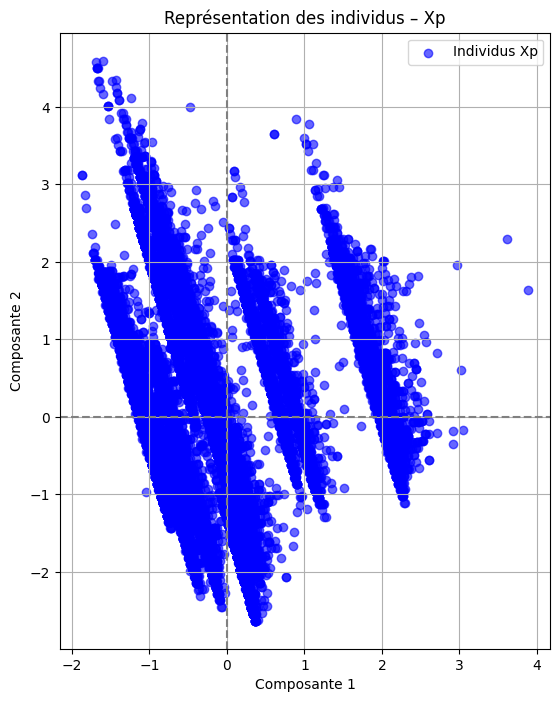

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))


plt.scatter(C_Xp[:,0], C_Xp[:,1], color='blue', alpha=0.6, label='Individus Xp')

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Représentation des individus – Xp")
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()

the individuals Xq representation

Le graphique CCA montre des bandes parallèles inclinées : elles correspondent à des sous-groupes d’individus définis par les catégories de job.

•	Chaque bande sur le graphique correspond à un groupe de personnes ayant le même job.

Les bandes ne sont pas droites verticalement car âge et solde varient à l’intérieur de chaque catégorie de job, ce qui crée une orientation inclinée dans le graphique.

Les individus les plus éloignés du centre sont ceux dont le profil Xp (âge, balance, job) est le plus marqué et qui sont le plus fortement corrélés au bloc Xq.


Extrêmes sur l’axe 1 (Composante 1)

 Les points très à gauche ou très à droite correspondent aux individus qui sont très différents de la moyenne par rapport aux variables Xp  et qui ont une relation forte avec le bloc .
À droite (extrême positif) : individus dont le job, l’âge ou le solde sont fortement associés positivement à la première corrélation canonique.
À gauche (extrême négatif) : individus dont le job, l’âge ou le solde sont fortement associés négativement.

Extrêmes sur l’axe 2 (Composante 2)

Les points très en haut ou très en bas correspondent aux individus qui suivent un deuxième schéma de corrélation, indépendant du premier.
En haut (extrême positif) : profil fortement corrélé positivement avec la deuxième relation canonique.
En bas (extrême négatif) : profil fortement corrélé négativement.
 Cet axe oppose souvent des sous-groupes différents de jobs ou des variations d’âge/solde non expliquées par l’axe 1.


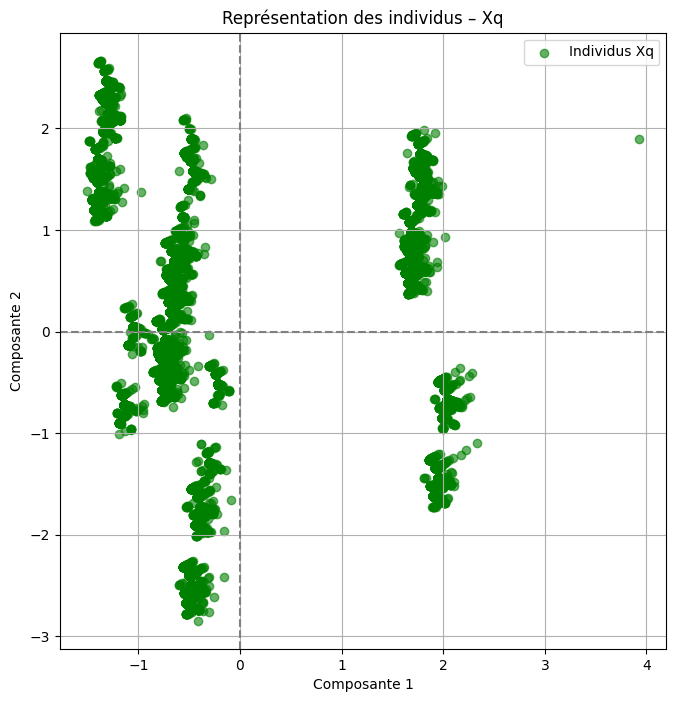

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(C_Xq[:,0], C_Xq[:,1], color='green', alpha=0.6, label='Individus Xq')

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Représentation des individus – Xq")
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()


Groupes homogènes :
Les nuages de points rapprochés représentent des sous-groupes d’individus ayant des profils Xq similaires (ex. même type de logement, prêt, situation maritale…).

Axes de séparation :

Composante 1 (CC1) : schéma principal de variation dans Xq, les individus sont séparés selon la combinaison linéaire dominante des variables Xq.

Composante 2 (CC2) : schéma secondaire, indépendant de CC1, souvent lié à d’autres caractéristiques comme l’éducation ou le statut marital.

Symétrie autour de 0 :
Les données sont centrées automatiquement par le CCA, donc la majorité des points se trouvent autour de l’origine.

**Dispersion sur les axes :**

Composante 1  :
 sépare les individus selon un critère dominant lié à une combinaison linéaire des variables Xq.

Composante 2 :
 sépare les individus selon un autre critère, probablement lié à l’éducation ou au statut marital.

**Symétrie autour de l’origine :**

Beaucoup de points sont centrés autour de 0, ce qui est attendu puisque le CCA centre les données.

Les points éloignés de l’origine sont des individus atypiques ou ayant des combinaisons de caractéristiques extrêmes ou bien spécifiques.

the individuals representation combining Xp and Xq

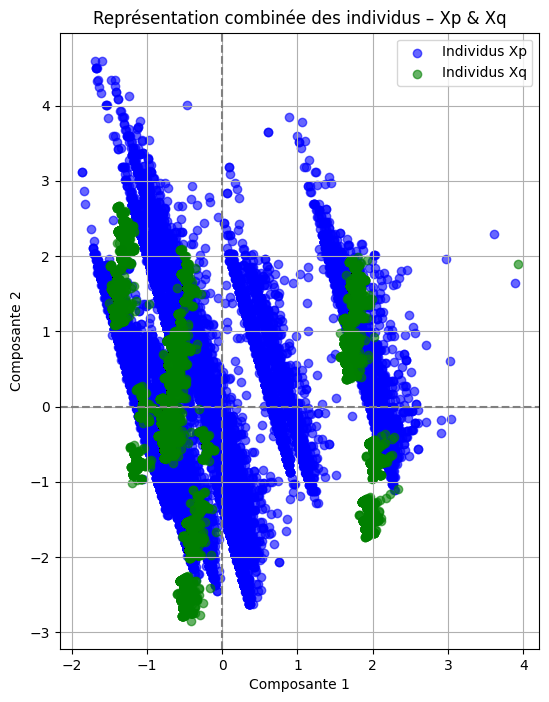

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(C_Xp[:,0], C_Xp[:,1], color='blue', alpha=0.6, label='Individus Xp')
plt.scatter(C_Xq[:,0], C_Xq[:,1], color='green', alpha=0.6, label='Individus Xq')

plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.title("Représentation combinée des individus – Xp & Xq")
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()

Le groupe Xp (bleu) présente une forte variabilité sur les deux axes : il est largement dispersé, forme des bandes inclinées correspondant à des sous-groupes (notamment liés au job) et montre plusieurs individus aux positions extrêmes. Cela indique que Xp contient des profils très hétérogènes et fortement influencés par les relations canoniques.

À l’inverse, le groupe Xq (vert) est beaucoup plus compact, avec très peu d’individus éloignés du centre. Il reste concentré autour de l’origine sur les deux composantes, montrant que Xq est un groupe homogène, moins impacté par les axes canoniques.

Sur l’axe 1, la séparation entre les individus est principalement portée par Xp, tandis que Xq reste faiblement dispersé.

Sur l’axe 2, Xp continue de montrer une certaine dispersion et des profils atypiques, alors que Xq demeure très centré.

✔ Le groupe Xp change beaucoup d’un individu à l’autre → il apporte beaucoup d'information

✔ Le groupe Xq change peu entre les individus → il apporte peu de variation




### CCA Conclusion
Based on your visualizations, do you think it would be useful to use the CCA results to reduce the dimensionality of your dataset before applying some form of clustering method, like you did with PCA? Why / why not?

D’après les visualisations de la CCA, il ne serait pas réellement pertinent d’utiliser les composantes canoniques pour réduire la dimension du jeu de données avant un clustering. En effet, la CCA ne cherche pas à capturer la variance interne des données comme le fait la PCA ; elle maximise la corrélation entre deux blocs de variables (Xp et Xq).

Or, les résultats montrent que :

Xp présente une forte variabilité et génère une dispersion importante sur les axes canoniques ;

Xq est au contraire très compact et n’apporte que très peu de variation.

Cette asymétrie indique que les axes issus de la CCA reflètent principalement l’hétérogénéité du bloc Xp, mais ne révèlent pas une structure globale dans l’ensemble des données, nécessaire pour un clustering efficace. Les composantes canoniques sont donc optimisées pour la corrélation entre blocs, et non pour la séparation entre individus.

Contrairement à la PCA, la CCA :

n’est pas conçue pour réduire les dimensions tout en conservant l’inertie globale,

ne garantit pas que les individus seront bien séparés dans l’espace transformé,

peut même déformer la structure utile au clustering lorsque les blocs ont des variabilités très différentes (ce qui est le cas ici).

 Ainsi, la CCA n’apporterait pas un espace plus adapté au clustering que les données originales ou que la PCA.

En conclusion, il n’est pas recommandé d’utiliser la CCA comme étape de réduction dimensionnelle avant un clustering, car ses axes ne sont pas optimisés pour capturer la structure des groupes naturels dans les données. La PCA reste plus appropriée pour cette tâche.
